# PROJECT: HANOI AIR QUALITY ANALYSIS (LINEAR REGRESSION)

## 1. Import Libraries

In [161]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import folium

from datetime import datetime
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

## 2. Helper Functions and Feature Engineering

In [162]:
def extract_features(df):
    df = df.copy()

    if 'Local Time' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['Local Time']):
        df['Local Time'] = pd.to_datetime(df['Local Time'])

    df['hour'] = df['Local Time'].dt.hour
    df['day_of_week'] = df['Local Time'].dt.dayofweek

    df['AQI_lag_1'] = df['AQI'].shift(1)
    df['AQI_lag_3'] = df['AQI'].shift(3)
    df['AQI_lag_24'] = df['AQI'].shift(24)

    df['temp_humidity'] = df['Temperature'] * df['Relative Humidity']
    df['pm25_wind'] = df['PM25'] * df['Wind Speed']

    base_features = [
        'Temperature', 'Relative Humidity', 'Wind Speed', 'Precipitation',
        'hour', 'day_of_week',
        'PM25', 'PM10', 'CO', 'NO2', 'O3', 'SO2',
        'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_24'
    ]

    interaction_features = ['temp_humidity', 'pm25_wind']
    all_features = base_features + interaction_features

    df_clean = df.dropna(subset=all_features + ['AQI', 'Local Time']).reset_index(drop=True)

    return df_clean, all_features, base_features, interaction_features


def prepare_data(train_raw, valid_raw, test_raw):
    print("Extracting features for Train...")
    train_clean, all_features, base_features, interaction_features = extract_features(train_raw)

    print("Extracting features for Valid...")
    valid_clean, _, _, _ = extract_features(valid_raw)

    print("Extracting features for Test...")
    test_clean, _, _, _ = extract_features(test_raw)

    X_train_raw = train_clean[all_features].values
    y_train = train_clean['AQI'].values

    X_valid_raw = valid_clean[all_features].values
    y_valid = valid_clean['AQI'].values

    X_test_raw = test_clean[all_features].values
    y_test = test_clean['AQI'].values

    print("Applying polynomial features (degree=2) on Train data...")
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_raw)
    X_valid_poly = poly.transform(X_valid_raw)
    X_test_poly = poly.transform(X_test_raw)

    feature_names = poly.get_feature_names_out(all_features)

    print("Applying StandardScaler on Train data...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_poly)
    X_valid = scaler.transform(X_valid_poly)
    X_test = scaler.transform(X_test_poly)

    historical_clean = pd.concat([train_clean, valid_clean, test_clean], ignore_index=True)
    historical_clean = historical_clean.sort_values('Local Time').reset_index(drop=True)

    return {
        'X_train': X_train,
        'y_train': y_train,
        'train_dates': train_clean['Local Time'].values,

        'X_valid': X_valid,
        'y_valid': y_valid,
        'valid_dates': valid_clean['Local Time'].values,

        'X_test': X_test,
        'y_test': y_test,
        'test_dates': test_clean['Local Time'].values,

        'df_clean': historical_clean,
        'feature_names': feature_names,
        'base_feature_names': base_features,
        'interaction_feature_names': interaction_features,
        'scaler': scaler,
        'poly_transformer': poly
    }


class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.n_iters = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
        self.val_cost_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.cost_history = []
        self.val_cost_history = []

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            train_cost = (1 / (2 * n_samples)) * np.sum((y_pred - y) ** 2)
            self.cost_history.append(train_cost)

            if X_val is not None and y_val is not None:
                y_val_pred = np.dot(X_val, self.weights) + self.bias
                val_cost = (1 / (2 * X_val.shape[0])) * np.sum((y_val_pred - y_val) ** 2)
                self.val_cost_history.append(val_cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


def classify_aqi(aqi_series):
    if isinstance(aqi_series, (int, float, np.integer, np.floating)):
        if aqi_series <= 50:
            return 'Good (0-50)'
        elif aqi_series <= 100:
            return 'Moderate (51-100)'
        elif aqi_series <= 150:
            return 'Unhealthy for Sensitive Groups (101-150)'
        elif aqi_series <= 200:
            return 'Unhealthy (151-200)'
        elif aqi_series <= 300:
            return 'Very Unhealthy (201-300)'
        else:
            return 'Hazardous (301+)'
    else:
        bins = [-np.inf, 50, 100, 150, 200, 300, np.inf]
        labels = [
            'Good (0-50)',
            'Moderate (51-100)',
            'Unhealthy for Sensitive Groups (101-150)',
            'Unhealthy (151-200)',
            'Very Unhealthy (201-300)',
            'Hazardous (301+)'
        ]
        return pd.cut(aqi_series, bins=bins, labels=labels)


def train_sklearn_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


def calculate_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }


def print_metrics(model_name, metrics):
    print(f"[{model_name}] Metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    print()

## 3. Import Data

In [163]:
train_path = 'TRAIN-mar-2023-dec-2024.csv'
valid_path = 'VALID-jan-2025-jul-2025.csv'
test_path = 'TEST-aug-2025-mar-2026.csv'

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
test_df = pd.read_csv(test_path)

print('Train shape:', train_df.shape)
print('Valid shape:', valid_df.shape)
print('Test shape:', test_df.shape)

raw_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)
raw_df.head()


Train shape: (16128, 18)
Valid shape: (5088, 18)
Test shape: (5832, 18)


,Local Time,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
0,2023-03-01 00:00:00,2023-02-28 17:00:00+00:00,Cau Giay,VN,Asia/Bangkok,150,800.0,60.7,17.0,48.3,32.4,18.5,2,0.0,1020.0,96,15.9,7.0
1,2023-03-01 01:00:00,2023-02-28 18:00:00+00:00,Cau Giay,VN,Asia/Bangkok,147,776.0,59.0,13.0,47.5,32.1,18.5,0,0.0,1019.7,97,15.6,6.8
2,2023-03-01 02:00:00,2023-02-28 19:00:00+00:00,Cau Giay,VN,Asia/Bangkok,144,762.0,56.3,11.0,48.0,32.6,18.2,7,0.0,1019.0,99,15.0,6.4
3,2023-03-01 03:00:00,2023-02-28 20:00:00+00:00,Cau Giay,VN,Asia/Bangkok,141,752.0,53.1,10.0,50.4,34.5,17.8,52,0.0,1018.7,100,14.8,6.2
4,2023-03-01 04:00:00,2023-02-28 21:00:00+00:00,Cau Giay,VN,Asia/Bangkok,138,747.0,49.0,9.0,56.0,38.5,17.3,100,0.0,1018.6,100,15.4,4.5


## 4. AQI Distribution and Trend

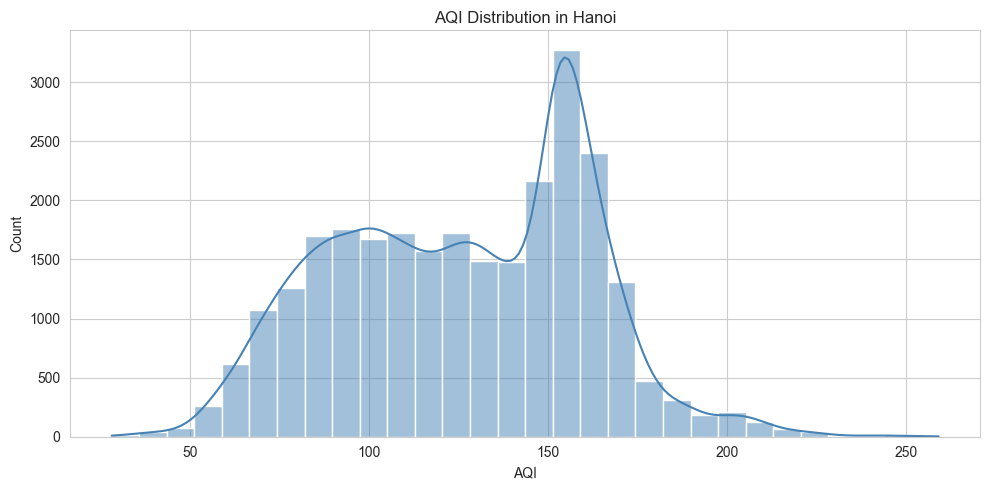

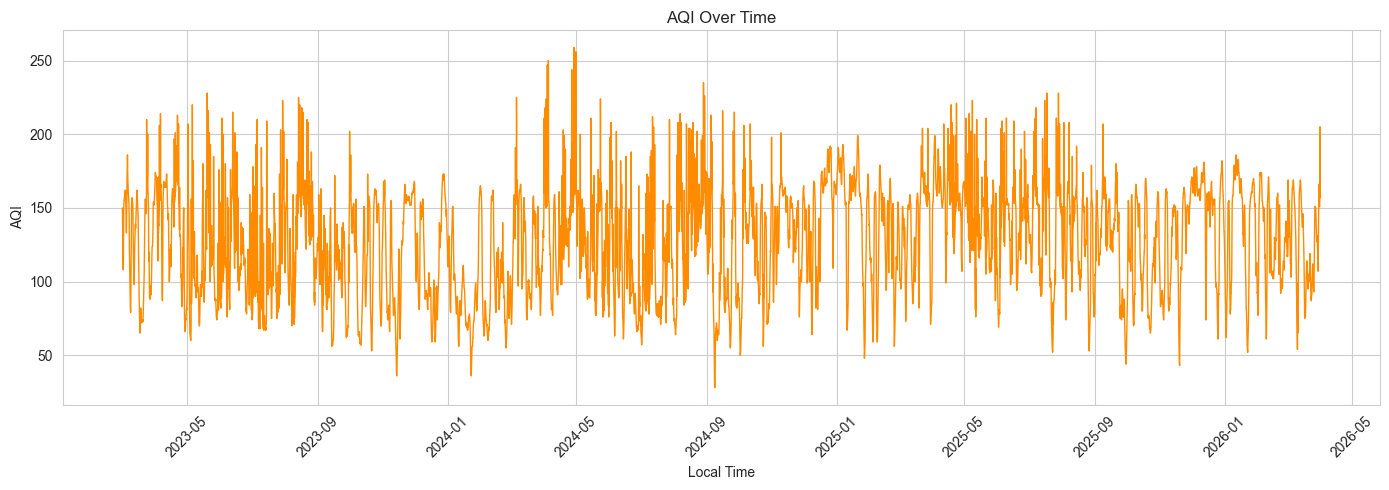

In [164]:
plt.figure(figsize=(10, 5))
sns.histplot(raw_df['AQI'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('AQI Distribution in Hanoi')
plt.xlabel('AQI')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
time_df = raw_df.copy()
time_df['Local Time'] = pd.to_datetime(time_df['Local Time'])
time_df = time_df.sort_values('Local Time')

plt.plot(time_df['Local Time'], time_df['AQI'], color='darkorange', linewidth=1)
plt.title('AQI Over Time')
plt.xlabel('Local Time')
plt.ylabel('AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. AQI by Hour and Weekday

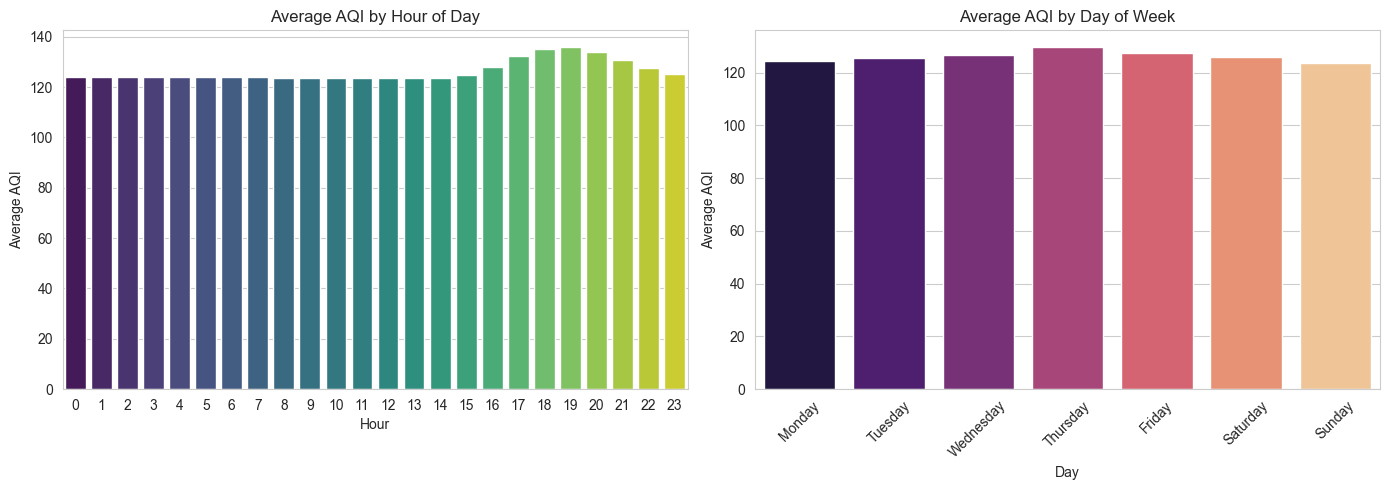

In [165]:
raw_df['Local Time'] = pd.to_datetime(raw_df['Local Time'])
raw_df['hour'] = raw_df['Local Time'].dt.hour
raw_df['day_of_week'] = raw_df['Local Time'].dt.day_name()

hourly_aqi = raw_df.groupby('hour')['AQI'].mean().reset_index()
weekday_aqi = raw_df.groupby('day_of_week')['AQI'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).reset_index()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=hourly_aqi, x='hour', y='AQI', palette='viridis')
plt.title('Average AQI by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average AQI')

plt.subplot(1, 2, 2)
sns.barplot(data=weekday_aqi, x='day_of_week', y='AQI', palette='magma')
plt.title('Average AQI by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

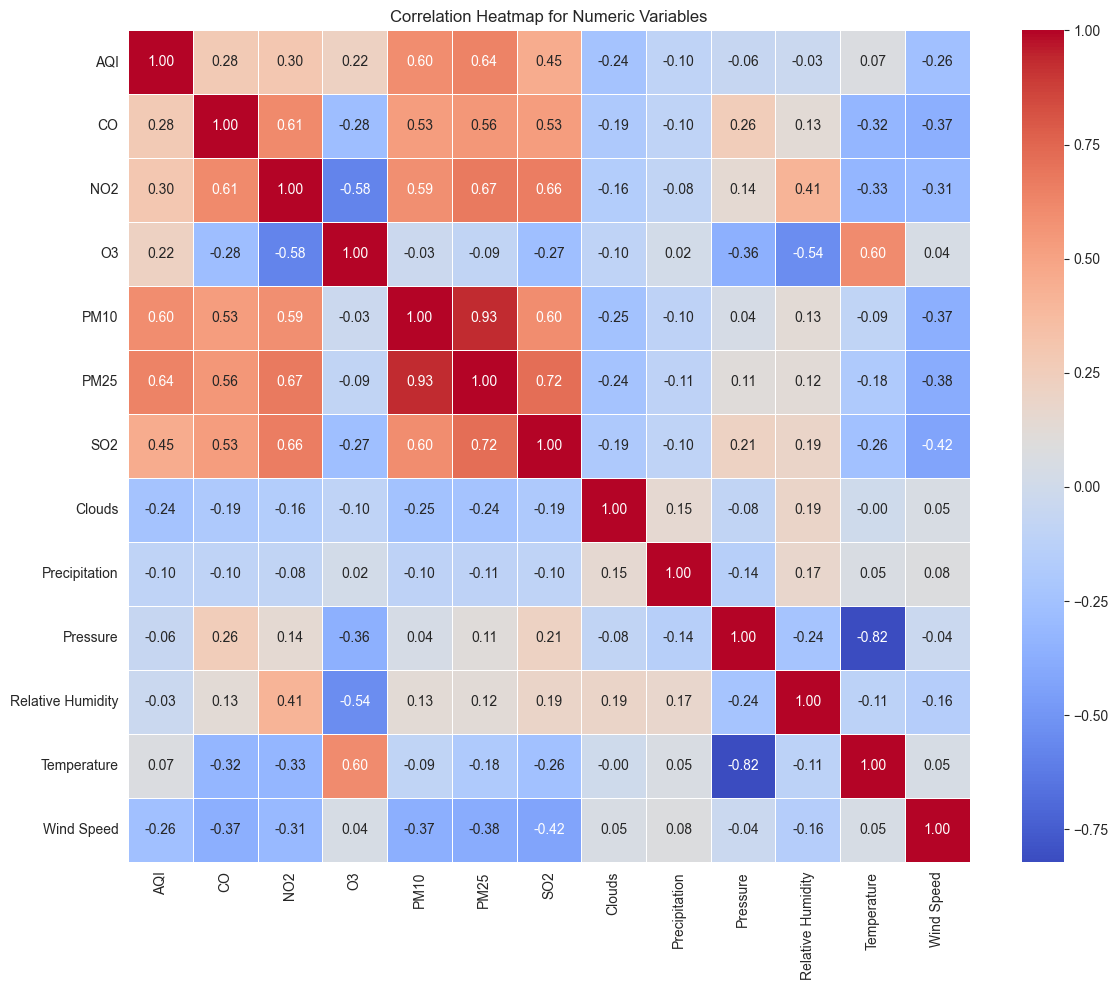

In [166]:
numeric_df = raw_df.select_dtypes(include=['float64', 'int64']).copy()

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Numeric Variables')
plt.tight_layout()
plt.show()

## 7. AQI Outlier Analysis

In [167]:
q1 = raw_df['AQI'].quantile(0.25)
q3 = raw_df['AQI'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = raw_df[(raw_df['AQI'] < lower_bound) | (raw_df['AQI'] > upper_bound)]

print(f'Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}')
print('Number of AQI outliers:', len(outliers))

Lower bound: 10.00, Upper bound: 242.00
Number of AQI outliers: 17


## 8. AQI Category Table

In [168]:
raw_df['AQI_Category'] = classify_aqi(raw_df['AQI'])
category_counts = raw_df['AQI_Category'].value_counts().reset_index()
category_counts.columns = ['AQI Category', 'Count']

category_counts

,AQI Category,Count
0,Unhealthy for Sensitive Groups (101-150),10463
1,Unhealthy (151-200),8648
2,Moderate (51-100),7432
3,Very Unhealthy (201-300),392
4,Good (0-50),113
5,Hazardous (301+),0


## 9. AQI Category Distribution Plot

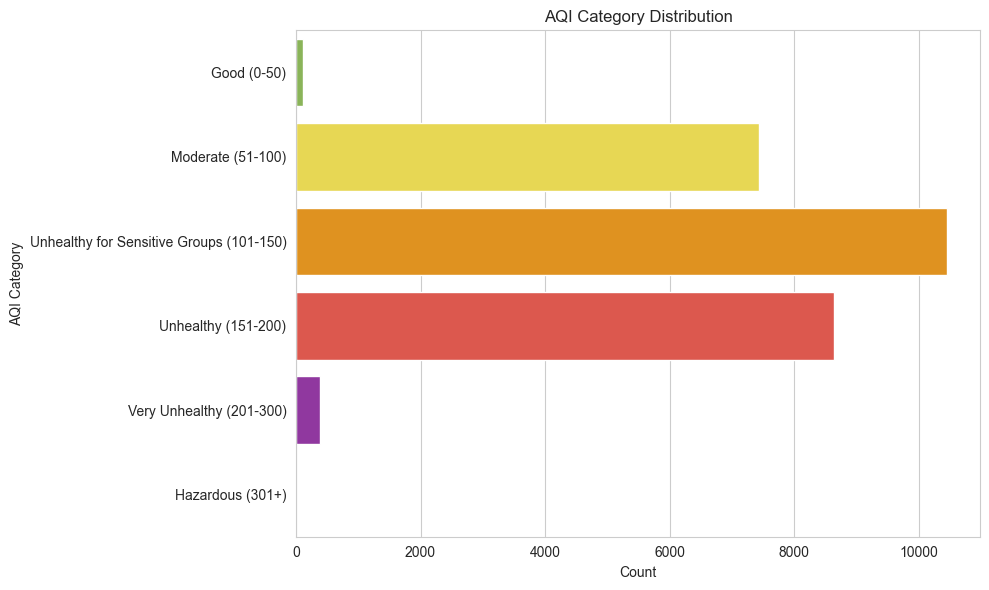

,AQI Category,Count
0,Good (0-50),113
1,Moderate (51-100),7432
2,Unhealthy for Sensitive Groups (101-150),10463
3,Unhealthy (151-200),8648
4,Very Unhealthy (201-300),392
5,Hazardous (301+),0


In [ ]:
raw_df['AQI_Category'] = classify_aqi(raw_df['AQI'])

aqi_order = [
    'Good (0-50)',
    'Moderate (51-100)',
    'Unhealthy for Sensitive Groups (101-150)',
    'Unhealthy (151-200)',
    'Very Unhealthy (201-300)',
    'Hazardous (301+)'
]

category_counts = raw_df['AQI_Category'].value_counts().reindex(aqi_order).reset_index()
category_counts.columns = ['AQI Category', 'Count']
category_counts['Count'] = category_counts['Count'].fillna(0).astype(int)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=raw_df,
    y='AQI_Category',
    order=aqi_order,
    palette=['#8bc34a', '#ffeb3b', '#ff9800', '#f44336', '#9c27b0', '#7e0023']
)
plt.title('AQI Category Distribution')
plt.xlabel('Count')
plt.ylabel('AQI Category')
plt.tight_layout()
plt.show()

category_counts

The dataset often shows imbalance across categories: common cases such as Moderate and Unhealthy for Sensitive Groups dominate the historical data, while Hazardous events are much rarer. This imbalance means the model should be evaluated carefully on high-AQI conditions rather than relying only on overall error metrics.

## 10. Feature Preparation and Train-Test Split

In [170]:
data_dict = prepare_data(train_df, valid_df, test_df)

X_train = data_dict['X_train']
y_train = data_dict['y_train']

X_valid = data_dict['X_valid']
y_valid = data_dict['y_valid']

X_test = data_dict['X_test']
y_test = data_dict['y_test']

dates = data_dict['test_dates']
df_clean = data_dict['df_clean']
feature_names = data_dict['feature_names']
base_feature_names = data_dict['base_feature_names']
interaction_feature_names = data_dict['interaction_feature_names']

print(f'Train samples: {X_train.shape[0]} / Valid samples: {X_valid.shape[0]} / Test samples: {X_test.shape[0]}')
print(f'Feature dimension after polynomial expansion: {X_train.shape[1]}')

Extracting features for Train...
Extracting features for Valid...
Extracting features for Test...
Applying polynomial features (degree=2) on Train data...
Applying StandardScaler on Train data...
Train samples: 16104 / Valid samples: 5064 / Test samples: 5808
Feature dimension after polynomial expansion: 170


## 11. Engineered Feature Review

In [171]:
print("Base features used in modeling:\n")
print(base_feature_names)

print("\nInteraction features created:\n")
print(interaction_feature_names)

print("\nNumber of polynomial feature outputs:", len(feature_names))

df_clean[['Local Time', 'AQI', 'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_24', 'hour', 'day_of_week']].head()

Base features used in modeling:

['Temperature', 'Relative Humidity', 'Wind Speed', 'Precipitation', 'hour', 'day_of_week', 'PM25', 'PM10', 'CO', 'NO2', 'O3', 'SO2', 'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_24']

Interaction features created:

['temp_humidity', 'pm25_wind']

Number of polynomial feature outputs: 170


,Local Time,AQI,AQI_lag_1,AQI_lag_3,AQI_lag_24,hour,day_of_week
0,2023-03-02 00:00:00,124,119.0,111.0,150.0,0,3
1,2023-03-02 01:00:00,129,124.0,114.0,147.0,1,3
2,2023-03-02 02:00:00,135,129.0,119.0,144.0,2,3
3,2023-03-02 03:00:00,140,135.0,124.0,141.0,3,3
4,2023-03-02 04:00:00,144,140.0,129.0,138.0,4,3


## 12. Scikit-Learn Linear Regression

In [172]:
sklearn_model = train_sklearn_model(X_train, y_train)

print("Scikit-learn model training completed.")
print("Number of features learned:", sklearn_model.coef_.shape[0])

Scikit-learn model training completed.
Number of features learned: 170


## 13. Scratch Linear Regression

In [173]:
scratch_model = LinearRegressionScratch(learning_rate=0.01, iterations=1000)
scratch_model.fit(X_train, y_train, X_val=X_valid, y_val=y_valid)

print('Scratch model training completed.')
print(f'Final training cost: {scratch_model.cost_history[-1]:.4f}')

if scratch_model.val_cost_history:
    print(f'Final validation cost: {scratch_model.val_cost_history[-1]:.4f}')

Scratch model training completed.
Final training cost: 11.9083
Final validation cost: 12.6594


## 14. Model Performance Comparison

In [174]:
scratch_val_preds = scratch_model.predict(X_valid)
sklearn_val_preds = sklearn_model.predict(X_valid)

scratch_test_preds = scratch_model.predict(X_test)
sklearn_test_preds = sklearn_model.predict(X_test)

print("\n" + "=" * 35)
print("     VALIDATION SET METRICS    ")
print("=" * 35)
print_metrics('Scratch Linear Regression', calculate_metrics(y_valid, scratch_val_preds))
print_metrics('Scikit-Learn Linear Regression', calculate_metrics(y_valid, sklearn_val_preds))

print("\n" + "=" * 35)
print("        TEST SET METRICS       ")
print("=" * 35)

scratch_metrics = calculate_metrics(y_test, scratch_test_preds)
sklearn_metrics = calculate_metrics(y_test, sklearn_test_preds)

print_metrics('Scratch Linear Regression', scratch_metrics)
print_metrics('Scikit-Learn Linear Regression', sklearn_metrics)

scratch_preds = scratch_test_preds
sklearn_preds = sklearn_test_preds


     VALIDATION SET METRICS    
[Scratch Linear Regression] Metrics:
  MAE: 3.3779
  MSE: 25.3188
  RMSE: 5.0318
  R2: 0.9759

[Scikit-Learn Linear Regression] Metrics:
  MAE: 2.5973
  MSE: 18.1660
  RMSE: 4.2622
  R2: 0.9827


        TEST SET METRICS       
[Scratch Linear Regression] Metrics:
  MAE: 2.5098
  MSE: 11.5929
  RMSE: 3.4048
  R2: 0.9891

[Scikit-Learn Linear Regression] Metrics:
  MAE: 1.6056
  MSE: 6.0478
  RMSE: 2.4592
  R2: 0.9943



## 15. Plot Scratch Model Cost Over Iterations

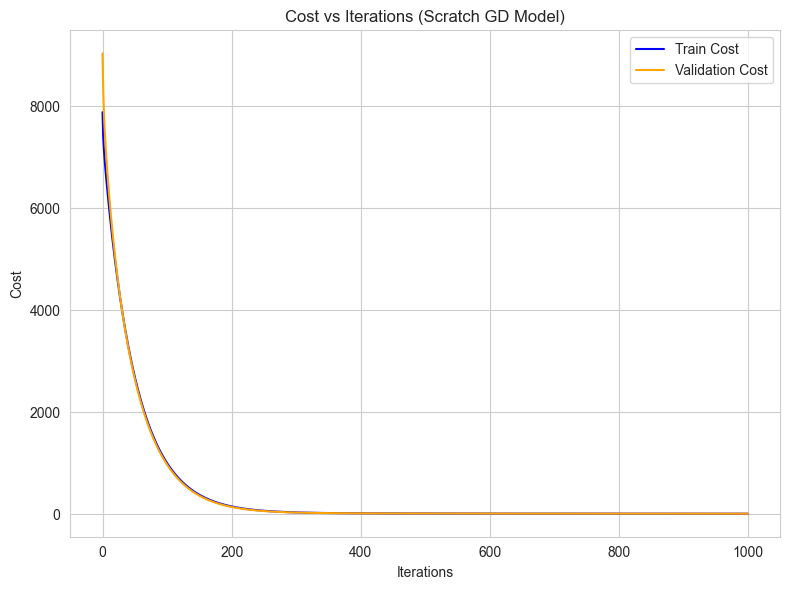

In [175]:
plt.figure(figsize=(8, 6))
plt.plot(range(len(scratch_model.cost_history)), scratch_model.cost_history, color='blue', label='Train Cost')

if scratch_model.val_cost_history:
    plt.plot(range(len(scratch_model.val_cost_history)), scratch_model.val_cost_history, color='orange', label='Validation Cost')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs Iterations (Scratch GD Model)')
plt.legend()
plt.tight_layout()
plt.show()

The scratch model uses gradient descent, which may converge more slowly and be sensitive to learning rate. The scikit-learn implementation uses an optimized closed-form solver under the hood, so it often achieves more stable results for linear regression on this engineered feature set.

## 16. Real-Time Multi-District AQI Prediction & Map

In [176]:
import pandas as pd
import numpy as np
import requests

districts = [
    {"District": "Cau Giay",     "Latitude": 21.0362, "Longitude": 105.7827},
    {"District": "Thanh Xuan",   "Latitude": 20.9933, "Longitude": 105.8117},
    {"District": "Hoang Mai",    "Latitude": 20.9800, "Longitude": 105.8600},
    {"District": "Nam Tu Liem",  "Latitude": 21.0200, "Longitude": 105.7500},
    {"District": "Ha Dong",      "Latitude": 20.9700, "Longitude": 105.7800},
    {"District": "Bac Tu Liem",  "Latitude": 21.0700, "Longitude": 105.7500},
]

def fetch_and_predict_district(lat, lon, model, scaler, poly_transformer):
    """Fetch real-time features for a district and return predicted + actual AQI."""
    timezone = "Asia/Bangkok"

    weather_url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}"
        f"&current=temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m"
        f"&timezone={timezone}"
    )
    aq_url = (
        f"https://air-quality-api.open-meteo.com/v1/air-quality?"
        f"latitude={lat}&longitude={lon}"
        f"&current=pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi"
        f"&hourly=us_aqi"
        f"&past_days=1"
        f"&timezone={timezone}"
    )

    weather_data = requests.get(weather_url, timeout=30).json()
    aq_data = requests.get(aq_url, timeout=30).json()

    weather = weather_data["current"]
    aq_curr = aq_data["current"]
    api_time = pd.to_datetime(weather["time"])
    hourly_pairs = [
        (pd.to_datetime(t), aqi)
        for t, aqi in zip(aq_data["hourly"]["time"], aq_data["hourly"]["us_aqi"])
        if aqi is not None and pd.to_datetime(t) <= api_time
    ]
    if len(hourly_pairs) < 25:
        return None

    idx = len(hourly_pairs) - 1
    aqi_lag_1  = hourly_pairs[idx - 1][1]
    aqi_lag_3  = hourly_pairs[idx - 3][1]
    aqi_lag_24 = hourly_pairs[idx - 24][1]

    base_features = [
        weather["temperature_2m"],
        weather["relative_humidity_2m"],
        weather["wind_speed_10m"],
        weather["precipitation"],
        api_time.hour,
        api_time.dayofweek,
        aq_curr["pm2_5"],
        aq_curr["pm10"],
        aq_curr["carbon_monoxide"],
        aq_curr["nitrogen_dioxide"],
        aq_curr["ozone"],
        aq_curr["sulphur_dioxide"],
        aqi_lag_1,
        aqi_lag_3,
        aqi_lag_24
    ]

    temp_humidity = base_features[0] * base_features[1]
    pm25_wind    = base_features[6] * base_features[2]
    full_features = np.array([base_features + [temp_humidity, pm25_wind]])
    poly_features = poly_transformer.transform(full_features)
    scaled_features = scaler.transform(poly_features)
    predicted_aqi = model.predict(scaled_features)[0]
    actual_aqi = aq_curr.get("us_aqi", None)

    return predicted_aqi, actual_aqi, api_time

results = []
api_timestamp = None

for d in districts:
    try:
        out = fetch_and_predict_district(
            d["Latitude"], d["Longitude"],
            sklearn_model,
            data_dict["scaler"],
            data_dict["poly_transformer"]
        )
        if out is not None:
            predicted, actual, api_time = out
            if api_timestamp is None:
                api_timestamp = api_time
            results.append({
                "District":      d["District"],
                "Latitude":      d["Latitude"],
                "Longitude":     d["Longitude"],
                "Predicted_AQI": round(predicted, 1),
                "Actual_AQI":    actual,
                "Error":         round(predicted - actual, 1)
            })
    except Exception as e:
        print(f"Warning: {d['District']} failed — {e}")

df_map = pd.DataFrame(results)

print("=" * 65)
print("   HANOI MULTI-DISTRICT LIVE AQI PREDICTION REPORT")
print("=" * 65)
print(f"   API Timestamp:  {api_timestamp.strftime('%d/%m/%Y %H:%M') if api_timestamp else 'N/A'}")
print(f"   Districts:      {len(df_map)}")
print(f"   Mean Predicted: {df_map['Predicted_AQI'].mean():.1f}")
print(f"   Mean Actual:    {df_map['Actual_AQI'].mean():.1f}")
print(f"   Mean Abs Error: {df_map['Error'].abs().mean():.1f}")
print("=" * 65)
display(df_map)

   HANOI MULTI-DISTRICT LIVE AQI PREDICTION REPORT
   API Timestamp:  14/04/2026 16:30
   Districts:      6
   Mean Predicted: 199.1
   Mean Actual:    198.2
   Mean Abs Error: 2.9


,District,Latitude,Longitude,Predicted_AQI,Actual_AQI,Error
0,Cau Giay,21.0362,105.7827,189.2,189,0.2
1,Thanh Xuan,20.9933,105.8117,211.3,206,5.3
2,Hoang Mai,20.9800,105.8600,211.7,206,5.7
3,Nam Tu Liem,21.0200,105.7500,189.2,189,0.2
4,Ha Dong,20.9700,105.7800,204.1,210,-5.9
5,Bac Tu Liem,21.0700,105.7500,188.8,189,-0.2


In [ ]:
import folium

def get_aqi_info(aqi):
    if aqi <= 50:  return "#8bc34a", "Good"
    if aqi <= 100: return "#ffeb3b", "Moderate"
    if aqi <= 150: return "#ff9800", "Unhealthy for Sensitive Groups"
    if aqi <= 200: return "#f44336", "Unhealthy"
    if aqi <= 300: return "#9c27b0", "Very Unhealthy"
    return "#7e0023", "Hazardous"

legend_html = '''
<div style="position: fixed; bottom: 30px; left: 50%; transform: translateX(-50%);
            width: 80%; height: 35px; z-index: 9999; border-radius: 8px;
            display: flex; overflow: hidden; font-family: sans-serif;
            font-size: 11px; font-weight: bold; border: 1px solid #555;">
    <div style="flex:1; background:#00e400; color:black; display:flex; align-items:center; justify-content:center;">Good</div>
    <div style="flex:1; background:#ffff00; color:black; display:flex; align-items:center; justify-content:center;">Moderate</div>
    <div style="flex:2; background:#ff7e00; color:white; display:flex; align-items:center; justify-content:center;">Sensitive</div>
    <div style="flex:1; background:#ff0000; color:white; display:flex; align-items:center; justify-content:center;">Unhealthy</div>
    <div style="flex:1; background:#8f3f97; color:white; display:flex; align-items:center; justify-content:center;">V. Unhealthy</div>
    <div style="flex:1; background:#7e0023; color:white; display:flex; align-items:center; justify-content:center;">Hazardous</div>
</div>
'''

def build_aqi_map(df, aqi_column, title):
    """Build a folium map colored by the given AQI column."""
    avg_aqi = df[aqi_column].mean()
    avg_color, _ = get_aqi_info(avg_aqi)

    hanoi_center = [21.0285, 105.8521]
    hanoi_strict_bounds = [[20.92, 105.70], [21.12, 106.00]]

    m = folium.Map(
        location=hanoi_center,
        zoom_start=12,
        min_zoom=12,
        max_bounds=True,
        bounds=hanoi_strict_bounds,
        tiles="CartoDB DarkMatter"
    )

    folium.Rectangle(
        bounds=[[20.5, 105.0], [21.5, 107.0]],
        color=avg_color, fill=True, fill_color=avg_color,
        fill_opacity=0.20, weight=0
    ).add_to(m)

    title_html = f'''
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
                z-index: 9999; background: rgba(0,0,0,0.7); color: white;
                padding: 8px 20px; border-radius: 8px; font-family: sans-serif;
                font-size: 16px; font-weight: bold;">
        {title} (Avg: {avg_aqi:.0f})
    </div>
    '''
    m.get_root().html.add_child(folium.Element(title_html))

    for _, row in df.iterrows():
        aqi_val = row[aqi_column]
        color, label = get_aqi_info(aqi_val)

        popup_html = (
            f"<b>{row['District']}</b><br>"
            f"{aqi_column.replace('_', ' ')}: {aqi_val:.0f}<br>"
            f"Status: {label}"
        )

        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=18,
            color=color, fill=True, fill_color=color, fill_opacity=1.0,
            popup=folium.Popup(popup_html, max_width=220)
        ).add_to(m)

        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            icon=folium.DivIcon(
                html=f'<div style="font-size:10pt; color:black; font-weight:bold; '
                     f'text-align:center; position:relative; top:-6px;">'
                     f'{int(aqi_val)}</div>'
            )
        ).add_to(m)

    m.get_root().html.add_child(folium.Element(legend_html))
    return m

import base64
from IPython.display import display, HTML

def show_map(m):
    """Display a folium map without requiring notebook trust."""
    html = m._repr_html_()
    encoded = base64.b64encode(html.encode()).decode()
    display(HTML(f'<iframe src="data:text/html;base64,{encoded}" width="100%" height="500" style="border:none;"></iframe>'))

# MAP 1 — Predicted
predicted_map = build_aqi_map(df_map, "Predicted_AQI", "Predicted AQI (Linear Regression)")
predicted_map.save("map_predicted.html")
show_map(predicted_map)

In [178]:
# MAP 2 — Actual
actual_map = build_aqi_map(df_map, "Actual_AQI", "Actual AQI (Open-Meteo API)")
actual_map.save("map_actual.html")
show_map(actual_map)